# Filterpass — Model Benchmark Analysis

Comparison of SOTA deepfake detection models on **ASVspoof 2021 LA** (500ms chunked inference).

Metrics: EER ↓, RTF mean ↓, Latency mean ↓, F1 ↑, Accuracy ↑, VRAM peak ↓

In [91]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Load & clean CSV ──────────────────────────────────────────────────────────
# Some rows have extra leading columns (chunked_500ms, chunk_size) inserted
# before scored_utterances — normalise by reading raw lines and re-parsing.

EXPECTED_COLS = [
    "model", "dataset", "phase",
    "scored_utterances", "skipped_utterances",
    "parameters", "vram_load_gb", "vram_peak_gb",
    "eer_pct", "min_tdcf", "auc_roc",
    "far_at_eer_pct", "frr_at_eer_pct",
    "accuracy_pct", "precision", "recall", "f1",
    "rtf_mean", "rtf_median", "rtf_p95", "rtf_max",
    "latency_mean_ms", "latency_median_ms", "latency_p95_ms",
]

CSV_PATH = "../results/metrics_summary.csv"

clean_lines = []
with open(CSV_PATH) as f:
    for i, line in enumerate(f):
        line = line.rstrip("\n")
        if not line.strip():
            continue
        parts = line.split(",")
        # Drop trailing empty fields
        while parts and parts[-1] == "":
            parts.pop()
        if i == 0:
            # Header — keep as-is for column count reference
            clean_lines.append(",".join(EXPECTED_COLS))
            continue
        # If row has more fields than expected, extra columns were inserted
        # after the 3rd fixed field (model, dataset, phase).
        # Strip them until we're at the right count.
        while len(parts) > len(EXPECTED_COLS):
            parts.pop(3)
        if len(parts) < len(EXPECTED_COLS):
            # Pad with NaN
            parts += [""] * (len(EXPECTED_COLS) - len(parts))
        clean_lines.append(",".join(parts))

df = pd.read_csv(io.StringIO("\n".join(clean_lines)))
df["model"] = df["model"].str.strip()

# Coerce numeric columns
num_cols = EXPECTED_COLS[3:]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

df[["model", "eer_pct", "rtf_mean", "latency_mean_ms", "f1", "accuracy_pct", "vram_peak_gb"]]

,model,eer_pct,rtf_mean,latency_mean_ms,f1,accuracy_pct,vram_peak_gb
0,XLSR-Mamba,6.96,0.0405,20.2,0.7278,93.04,1.51
1,Filterpass-SAP (ours),10.10,0.0041,2.1,0.6250,89.90,2.34
2,Wav2Vec2-AASIST,5.81,0.0037,1.9,0.7643,94.19,2.37
3,Nes2NetX,6.40,0.0071,3.5,0.7452,93.60,2.37
4,TCM,9.59,0.0033,1.6,0.6535,90.41,2.40


In [ ]:
import seaborn as sns

sns.set_theme(style="white", font_scale=1)

FILTERPASS = "Filterpass-SAP"
palette = sns.color_palette("mako", n_colors=len(df))
models = df["model"].tolist()
x = np.arange(len(models))

# ── EER — standalone ──────────────────────────────────────────────────────────
vals = df["eer_pct"].tolist()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(x, vals, color=palette, width=0.4)
for bar, v in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(vals) * 0.015,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

best = int(np.nanargmin(vals))
bars[best].set_edgecolor("#FFD700")
bars[best].set_linewidth(1.5)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8)
for tick, m in zip(ax.get_xticklabels(), models):
    if m.startswith(FILTERPASS):
        tick.set_fontweight("bold")

ax.set_ylabel("EER (%)")
ax.set_title("EER (%)  (↓ lower better)", pad=20)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../results/eer-pct.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILTERPASS = "Filterpass-SAP"
rtf_vals = df["rtf_mean"].tolist()
lat_vals = df["latency_mean_ms"].tolist()

x = np.arange(len(models))
width = 0.38

fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

ax1.grid(False)
ax2.grid(False)

mako = sns.color_palette("mako", 6)
c_rtf = mako[1]
c_lat = mako[4]

bars_rtf = ax1.bar(x - width / 2, rtf_vals, width, color=c_rtf, label="RTF Mean ↓")
bars_lat = ax2.bar(x + width / 2, lat_vals, width, color=c_lat, label="Latency Mean (ms) ↓")

ax1.bar_label(bars_rtf, fmt='%.4f', padding=4, color=c_rtf, fontsize=8.5)
ax2.bar_label(bars_lat, fmt='%.1f', padding=4, color=c_lat, fontsize=8.5)

best_rtf = int(np.nanargmin(rtf_vals))
best_lat = int(np.nanargmin(lat_vals))
bars_rtf[best_rtf].set_edgecolor("#FFD700"); bars_rtf[best_rtf].set_linewidth(2.5)
bars_lat[best_lat].set_edgecolor("#FFD700"); bars_lat[best_lat].set_linewidth(2.5)

ax1.set_ylabel("RTF Mean", color=c_rtf, fontweight="bold")
ax2.set_ylabel("Latency Mean (ms)", color=c_lat, fontweight="bold")
ax1.tick_params(axis="y", colors=c_rtf)
ax2.tick_params(axis="y", colors=c_lat)

ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=8)
for tick, m in zip(ax1.get_xticklabels(), models):
    if m.startswith(FILTERPASS):
        tick.set_fontweight("bold")

ax1.set_xlim(-0.5, len(models) - 0.5)
ax1.set_title("RTF Mean & Latency Mean by Model (↓ lower is better)", pad=20)

lines = [bars_rtf, bars_lat]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=9, framealpha=0.9)

sns.despine(ax=ax1, right=False)
plt.tight_layout(pad=1.5)
plt.savefig("../results/rtf-latency.png", dpi=150, bbox_inches="tight", pad_inches=0.4)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILTERPASS = "Filterpass-SAP"
f1_vals = df["f1"].tolist()
acc_raw = df["accuracy_pct"].tolist()
acc_vals = [val / 100 for val in acc_raw]

x = np.arange(len(models))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(False)

c_f1  = sns.color_palette("muted")[2]
c_acc = sns.color_palette("muted")[3]

bars_f1  = ax.bar(x - width / 2, f1_vals,  width, color=c_f1,  label="F1 ↑")
bars_acc = ax.bar(x + width / 2, acc_vals, width, color=c_acc, label="Accuracy ↑")

ax.bar_label(bars_f1, fmt='%.4f', padding=4, color=c_f1, fontsize=8.5)
acc_labels = [f"{val:.1f}%" for val in acc_raw]
ax.bar_label(bars_acc, labels=acc_labels, padding=4, color=c_acc, fontsize=8.5)

best_f1  = int(np.nanargmax(f1_vals))
best_acc = int(np.nanargmax(acc_vals))
bars_f1[best_f1].set_edgecolor("#FFD700");   bars_f1[best_f1].set_linewidth(2.5)
bars_acc[best_acc].set_edgecolor("#FFD700"); bars_acc[best_acc].set_linewidth(2.5)

ax.set_ylabel("Score (F1 Raw · Accuracy / 100)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8)
for tick, m in zip(ax.get_xticklabels(), models):
    if m.startswith(FILTERPASS):
        tick.set_fontweight("bold")

ax.set_xlim(-0.5, len(models) - 0.5)
ax.set_ylim(0, 1.15)
ax.set_title("F1 Score & Accuracy by Model (↑ higher is better)", pad=15)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

sns.despine(ax=ax)
plt.tight_layout(pad=1.5)
plt.savefig("../results/f1-accuracy.png", dpi=150, bbox_inches="tight", pad_inches=0.4)
plt.show()


In [ ]:
FILTERPASS = "Filterpass-SAP"

fp_idx = df[df["model"].str.startswith(FILTERPASS)].index[0]
_pal = sns.color_palette("mako", n_colors=len(df))
_colors = [(*c[:3], 0.4) for c in _pal]
_colors[fp_idx] = (*_pal[fp_idx][:3], 1.0)

order = df["vram_load_gb"].argsort().values
sorted_models = df["model"].iloc[order].tolist()
sorted_vram   = df["vram_load_gb"].iloc[order].tolist()
sorted_colors = [_colors[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sorted_models, sorted_vram, color=sorted_colors, height=0.5)

ax.grid(False)

fp_bar_idx = next(i for i, m in enumerate(sorted_models) if m.startswith(FILTERPASS))
bars[fp_bar_idx].set_edgecolor("#FFD700")
bars[fp_bar_idx].set_linewidth(2.5)

for bar, v, m in zip(bars, sorted_vram, sorted_models):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f} GB" + ("  ← ours" if m.startswith(FILTERPASS) else ""),
            va="center", fontsize=9,
            fontweight="bold" if m.startswith(FILTERPASS) else "normal")

for tick in ax.get_yticklabels():
    if tick.get_text().startswith(FILTERPASS):
        tick.set_fontweight("bold")

ax.set_xlabel("VRAM at load (GB)")
ax.set_title("VRAM footprint at load — Filterpass-SAP vs SOTA  (↓ lower better)", pad=10)
ax.set_xlim(0, max(sorted_vram) * 1.35)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../results/vram-load-gb.png", dpi=150, bbox_inches="tight")
plt.show()


## EER vs RTF tradeoff

Best models sit bottom-left (low EER, low RTF). RTF < 0.1 constraint shown as dashed line.

In [ ]:
FILTERPASS = "Filterpass-SAP"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
model_palette = {m: c for m, c in zip(df["model"], sns.color_palette("muted", n_colors=len(df)))}

fig, ax = plt.subplots(figsize=(9, 6))

for _, row in df.iterrows():
    is_fp = row["model"].startswith(FILTERPASS)
    ax.scatter(
        row["rtf_mean"], row["eer_pct"],
        color=model_palette[row["model"]], s=200, zorder=5,
        edgecolors="white", linewidths=0.8, label=row["model"],
    )
    ax.annotate(
        row["model"],
        xy=(row["rtf_mean"], row["eer_pct"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=9,
        fontweight="bold" if is_fp else "normal",
    )

ax.axvline(0.1, color="#E05252", linewidth=1.4, linestyle="--", label="RTF = 0.1 limit")

ax.set_xlabel("RTF mean  (↓ lower is faster)")
ax.set_ylabel("EER (%)  (↓ lower is more accurate)")
ax.set_title("EER vs RTF tradeoff", pad=30)
ax.legend(fontsize=9, loc='upper right', markerscale=0.5)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../results/eer_vs_rtf.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary table

## Filterpass-SAP: version comparison

EER and F1 across four training regimes:

| Version | Training data | Real-time aug |
|---------|--------------|---------------|
| v1 | Clean | No |
| v2 | Clean | Yes |
| v3 | Augmented | Yes |
| v4 | Augmented | No |

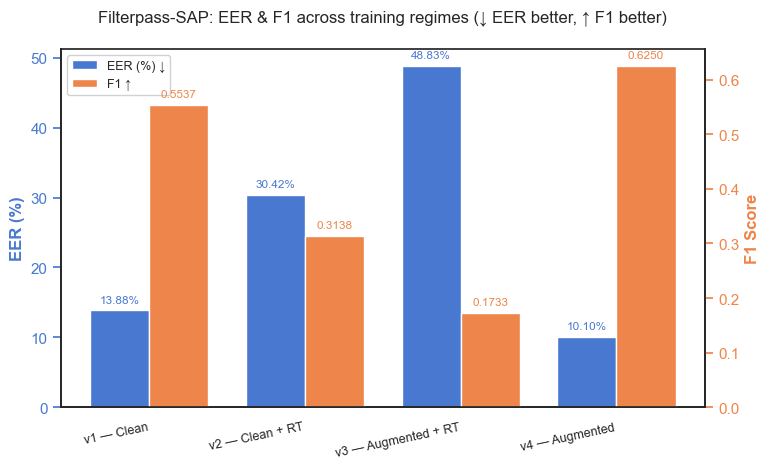

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration
VERSION_CSVS = {
    "v1 — Clean": "../results/ASVSpoof2021/filterpass-sap/metrics.csv",
    "v2 — Clean + RT": "../results/ASVSpoof2021/filterpass-sap-v2/metrics.csv",
    "v3 — Augmented + RT": "../results/ASVSpoof2021/filterpass-sap-v3/metrics.csv",
    "v4 — Augmented": "../results/ASVSpoof2021/filterpass-sap-v4/metrics.csv",
}

# 2. Load and consolidate data
frames = [pd.read_csv(path).assign(version=label) for label, path in VERSION_CSVS.items()]
df = pd.concat(frames, ignore_index=True)

# STRIP PANDAS METADATA to prevent auto-alignment issues
versions = df["version"].tolist()
eer_vals = df["eer_pct"].tolist()
f1_vals = df["f1"].tolist()

# 3. Setup Plot Configuration
x = np.arange(len(versions))
width = 0.38
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Explicitly disable the grid on both axes
ax1.grid(False)
ax2.grid(False)

color_eer, color_f1 = sns.color_palette("muted")[:2]

# 4. Plot the bars 
bars_eer = ax1.bar(x - width / 2, eer_vals, width, color=color_eer, label="EER (%) ↓")
bars_f1  = ax2.bar(x + width / 2, f1_vals,  width, color=color_f1,  label="F1 ↑")

# 5. Add value labels
ax1.bar_label(bars_eer, fmt='%.2f%%', padding=4, color=color_eer, fontsize=8.5)
ax2.bar_label(bars_f1,  fmt='%.4f',   padding=4, color=color_f1,  fontsize=8.5)

# 6. Axis labels and tick colors
ax1.set_ylabel("EER (%)", color=color_eer, fontweight="bold")
ax2.set_ylabel("F1 Score", color=color_f1, fontweight="bold")
ax1.tick_params(axis="y", colors=color_eer)
ax2.tick_params(axis="y", colors=color_f1)

# 7. X-axis formatting and Title
ax1.set_xticks(x)
ax1.set_xticklabels(versions, rotation=12, ha="right", fontsize=9)
ax1.set_title("Filterpass-SAP: EER & F1 across training regimes (↓ EER better, ↑ F1 better)", pad=20)

# 8. Legend and styling
lines = [bars_eer, bars_f1]
labels = ["EER (%) ↓", "F1 ↑"]
ax1.legend(lines, labels, loc="upper left", fontsize=9, framealpha=0.9)

sns.despine(ax=ax1, right=False) 

# 9. Final Layout & Save
plt.tight_layout(pad=1.5)
plt.savefig("../results/filterpass-sap-versions.png", dpi=150, bbox_inches="tight", pad_inches=0.4)
plt.show()